# Audit Komputasi Perselisihan Efisiensi Proteom 2024: Efek Warburg

**Notebook ringkasan pipeline** — IF3211 Komputasi Domain Spesifik

Notebook ini menelusuri **keseluruhan pipeline** audit komputasi terhadap dua makalah 2024 yang menyimpulkan hal berlawanan tentang jalur produksi ATP mana yang lebih efisien per massa protein:

| Makalah | Klaim | Besaran yang diukur |
|---------|-------|---------------------|
| **Shen dkk.** (*Nat. Chem. Biol.* 2024) | Respirasi lebih efisien per massa protein | Efisiensi **terealisasi** $u \cdot V \cdot \gamma$ |
| **Kukurugya dkk.** (*PNAS* 2024) | Glikolisis menghasilkan ATP lebih cepat per mg enzim | **Kapasitas** maksimal $V \cdot \gamma$ |

**Hipotesis audit:** keduanya benar — mereka hanya mengukur besaran yang berbeda. Kukurugya mengukur *kapasitas* (seolah semua enzim bekerja penuh, $u = 1$), sementara Shen mengukur *efisiensi terealisasi* (memperhitungkan bahwa sebagian enzim glikolitik menganggur, $u < 1$). Begitu fraksi pemanfaatan glikolitik $u_G$ turun di bawah rasio kapasitas $\rho$, verdict membalik dari "glikolisis menang" menjadi "respirasi menang".

## Alur pipeline

Notebook ini menjalankan modul secara berurutan, persis seperti `python main.py`:

```
M2  Provenance parameter  →  M1  Dua solver (LP + analitik)
        →  M3  Eksperimen audit (E1, E2, E2c, E2d, E4, Wang)
        →  M4  Identifiabilitas (E3 Sobol/Morris + E3b Sobol LP)
        →  M5  Visualisasi (8 figur)
```

> **Catatan waktu:** notebook ini dijalankan **live & penuh** (ukuran sampel sama persis dengan pipeline produksi). Sel **M4 (E3/E3b)** adalah yang paling lambat — analisis Sobol pada keluaran LP melibatkan puluhan ribu penyelesaian LP, sekitar **~60 detik**. Sel lain berjalan dalam hitungan detik.

## Setup

Sel berikut mengatur direktori kerja ke root repositori (agar `from src...` dan penulisan ke `results/` bekerja walau kernel dijalankan dari dalam folder `notebook/`), lalu mengimpor seluruh fungsi publik pipeline yang akan dipanggil.

In [1]:
import os
from pathlib import Path

# Pastikan working directory = root repo (notebook berada di notebook/)
ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
os.chdir(ROOT)
print("Working directory:", Path.cwd())

# Direktori output
Path("results").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# M2 — parameter provenance
from src.params import provenance_table, derived_table, ALL_ORGANISMS, ModelParams

# M1 — solver
from src.models import solve_shen, solve_kukurugya, compute_efficiency_with_utilization

# M3 — eksperimen audit
from src.audit import run_full_audit, run_wang_comparison, run_e4_all_organisms

# M4 — identifiabilitas
from src.identifiability import run_e3

# M5 — visualisasi
from src.viz import (
    plot_f1_overlay, plot_f2_verdict_flip, plot_f3_sobol_tornado,
    plot_f3_morris_scatter, plot_f3c_sobol_lp, plot_f5_wang_comparison,
    plot_f6_decomposition, plot_f7_phase_diagram,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print("Import selesai. Organisme tersedia:", list(ALL_ORGANISMS.keys()))

Working directory: /run/media/reletz/New Volume/ITB/Belajar/IF/Sem 6/IF3211 Komputasi Domain Spesifik/Tubes


Import selesai. Organisme tersedia: ['ecoli', 'yeast', 'mammalian']


## M2 — Provenance Parameter

Setiap konstanta numerik ditandai sumbernya (makalah, tabel/SI, organisme). Lima parameter inti per organisme:

- $\gamma_R$ (`gamma_resp`) — yield ATP per glukosa via respirasi
- $\gamma_G$ (`gamma_glyc`) — yield ATP per glukosa via glikolisis/fermentasi
- $V_R$ (`V_resp`), $V_G$ (`V_glyc`) — aktivitas spesifik enzim (µmol·min⁻¹·mg⁻¹)
- $\Phi$ (`Phi`) — fraksi proteom maksimal untuk enzim penghasil ATP

Dari sini diturunkan **kapasitas** $V\!\cdot\!\gamma$ tiap jalur dan **rasio kapasitas** $\rho = (V\!\cdot\!\gamma)_R / (V\!\cdot\!\gamma)_G$. Bila $\rho < 1$, glikolisis lebih cepat per protein pada kapasitas penuh (verdict Kukurugya).

In [2]:
prov = provenance_table()
prov

,organism,parameter,value,unit,source_paper,source_location,note
0,ecoli,gamma_resp,26.0000,mol ATP / mol glucose,kukurugya2024,"Table 1, SI Text S1",Full oxidative phosphorylation; P/O ratio ~2.5...
1,ecoli,gamma_glyc,2.0000,mol ATP / mol glucose,kukurugya2024,Table 1,Substrate-level phosphorylation only (glycolys...
2,ecoli,V_resp,0.0049,µmol glucose · min⁻¹ · mg protein⁻¹,kukurugya2024,SI Table S1,PROVISIONAL — rate-limiting step of respirator...
3,ecoli,V_glyc,0.2300,µmol glucose · min⁻¹ · mg protein⁻¹,kukurugya2024,SI Table S1,PROVISIONAL — glycolytic pathway specific acti...
4,ecoli,Phi,0.2600,dimensionless,kukurugya2024,"SI Table S2, proteomics",PROVISIONAL — fraction of proteome in ATP-gene...
5,yeast,gamma_resp,26.0000,mol ATP / mol glucose,kukurugya2024,Table 1,Full respiration; P/O ~2.5 for yeast mitochondria
6,yeast,gamma_glyc,2.0000,mol ATP / mol glucose,kukurugya2024,Table 1,Fermentation to ethanol: net 2 ATP per glucose
7,yeast,V_resp,0.0085,µmol glucose · min⁻¹ · mg protein⁻¹,kukurugya2024,SI Table S1,PROVISIONAL — respiratory pathway specific act...
8,yeast,V_glyc,0.4600,µmol glucose · min⁻¹ · mg protein⁻¹,kukurugya2024,SI Table S1,PROVISIONAL — glycolytic/fermentative specific...
9,yeast,Phi,0.2000,dimensionless,kukurugya2024,SI Table S2,PROVISIONAL


In [3]:
derived = derived_table()
derived

,organism,Vgamma_resp,Vgamma_glyc,rho (resp/glyc),verdict_capacity
0,ecoli,0.1274,0.46,0.276957,glycolysis
1,yeast,0.2210,0.92,0.240217,glycolysis
2,mammalian,0.1280,0.78,0.164103,glycolysis


## M1 — Dua Solver dengan Antarmuka Bersama

**Model A (gaya Shen)** — *linear program* 2-sektor. Sel mengalokasikan proteom antara sektor glikolitik ($\phi_G$) dan respiratorik ($\phi_R$) untuk memaksimalkan laju ATP:

$$\max\; J_\text{ATP} = \gamma_G J_{\text{glc},G} + \gamma_R J_{\text{glc},R}$$

dengan kendala kapasitas enzim $J_{\text{glc},i} \le V_i \phi_i$, anggaran proteom $\phi_G + \phi_R \le \Phi$, dan ketersediaan glukosa $\sum J_{\text{glc},i} \le g_\text{avail}$. Diselesaikan via `scipy.optimize.linprog` (backend HiGHS).

**Model B (gaya Kukurugya)** — model 5-parameter yang cukup kecil untuk memiliki **solusi analitik titik-sudut** (respirasi murni / glikolisis murni / campuran).

Keduanya menerima `ModelParams` yang sama dan mengembalikan `ModelResult` yang sama — inilah yang membuat perbandingan setara. Berikut demonstrasi pada satu titik untuk *E. coli*:

In [4]:
op = ALL_ORGANISMS["ecoli"]
g_star = op.V_resp.value * op.Phi.value           # ambang glukosa kritis
params = ModelParams.from_organism_params(op, g_avail=1.5 * g_star)

res_shen = solve_shen(params)
res_kuku = solve_kukurugya(params)

comparison = pd.DataFrame({
    "Model A (Shen, LP)":        res_shen.__dict__,
    "Model B (Kukurugya, analitik)": res_kuku.__dict__,
})
comparison

,"Model A (Shen, LP)","Model B (Kukurugya, analitik)"
phenotype,mixed,mixed
phi_G,0.00283,0.00283
phi_R,0.25717,0.25717
J_ATP,0.034065,0.034065
J_ATP_glyc,0.001302,0.001302
J_ATP_resp,0.032763,0.032763
frac_glyc,0.038213,0.038213
eps_ratio,0.276957,0.276957
g_avail,0.001911,0.001911


**Antarmuka efisiensi.** `compute_efficiency_with_utilization` menghitung kapasitas vs. terealisasi pada nilai pemanfaatan $u_G$ tertentu. Pada kapasitas penuh ($u_G = 1$) verdict mengikuti Kukurugya; turunkan $u_G$ dan margin akan membalik:

In [5]:
for uG in (1.0, 0.5, 0.2):
    eff = compute_efficiency_with_utilization(params, u_G=uG, u_R=1.0)
    print(f"u_G={uG:>4}: margin={eff['margin']:+.5f}  "
          f"verdict_realized={eff['verdict_realized']}")

u_G= 1.0: margin=-0.33260  verdict_realized=glycolysis
u_G= 0.5: margin=-0.10260  verdict_realized=glycolysis
u_G= 0.2: margin=+0.03540  verdict_realized=respiration


## M3 — Jalankan Audit Lengkap

`run_full_audit()` menjalankan E1, E2, E2b, E2c, dan E2d untuk ketiga organisme sekaligus, lalu menulis CSV ke `results/`. Hasilnya berupa dict berisi DataFrame per eksperimen.

In [6]:
audit_results = run_full_audit()
print("Kunci hasil audit:", list(audit_results.keys()))

[M3] Running E1 — shared-axis overlay for all organisms...


  → results/e1_overlay.csv (1800 rows)
[M3] Running E2 — capacity vs. realized sweep...
  → results/e2_capacity_vs_realized.csv (1500 rows)
       ecoli: capacity ρ = 0.2770, verdict flips at u_G = 0.2759
       yeast: capacity ρ = 0.2402, verdict flips at u_G = 0.2401
   mammalian: capacity ρ = 0.1641, verdict flips at u_G = 0.1628
[M3] Running E2b — enzyme accounting variation...
  → results/e2b_accounting.csv (150 rows)
[M3] Running E2c — uncertainty quantification (bootstrap CI)...
  → results/e2c_uncertainty.csv
       ecoli: flip u_G = 0.2766 [90% CI: 0.1590 – 0.4791]
       yeast: flip u_G = 0.2399 [90% CI: 0.1391 – 0.4145]
   mammalian: flip u_G = 0.1636 [90% CI: 0.0943 – 0.2846]
[M3] Running E2d — attribution decomposition...
  → results/e2d_decomposition.csv (150 rows)
       ecoli: max |Δ flip| from enzyme attribution = 0.238076 (vs flip ≈ 0.5143)
       yeast: max |Δ flip| from enzyme attribution = 0.204349 (vs flip ≈ 0.4461)
   mammalian: max |Δ flip| from enzyme attributi

### E1 — Overlay Dua Model pada Sumbu Bersama

Kedua model dijalankan pada grid glukosa identik per organisme, lalu diplot pada sumbu bersama (fraksi fermentatif vs. ketersediaan glukosa). **Temuan:** kurva keduanya nyaris berimpit — zona ketidaksetujuan ($|\Delta| > 0{,}1$, area merah muda) sangat sempit. Perselisihan bukan soal "model mana yang benar".

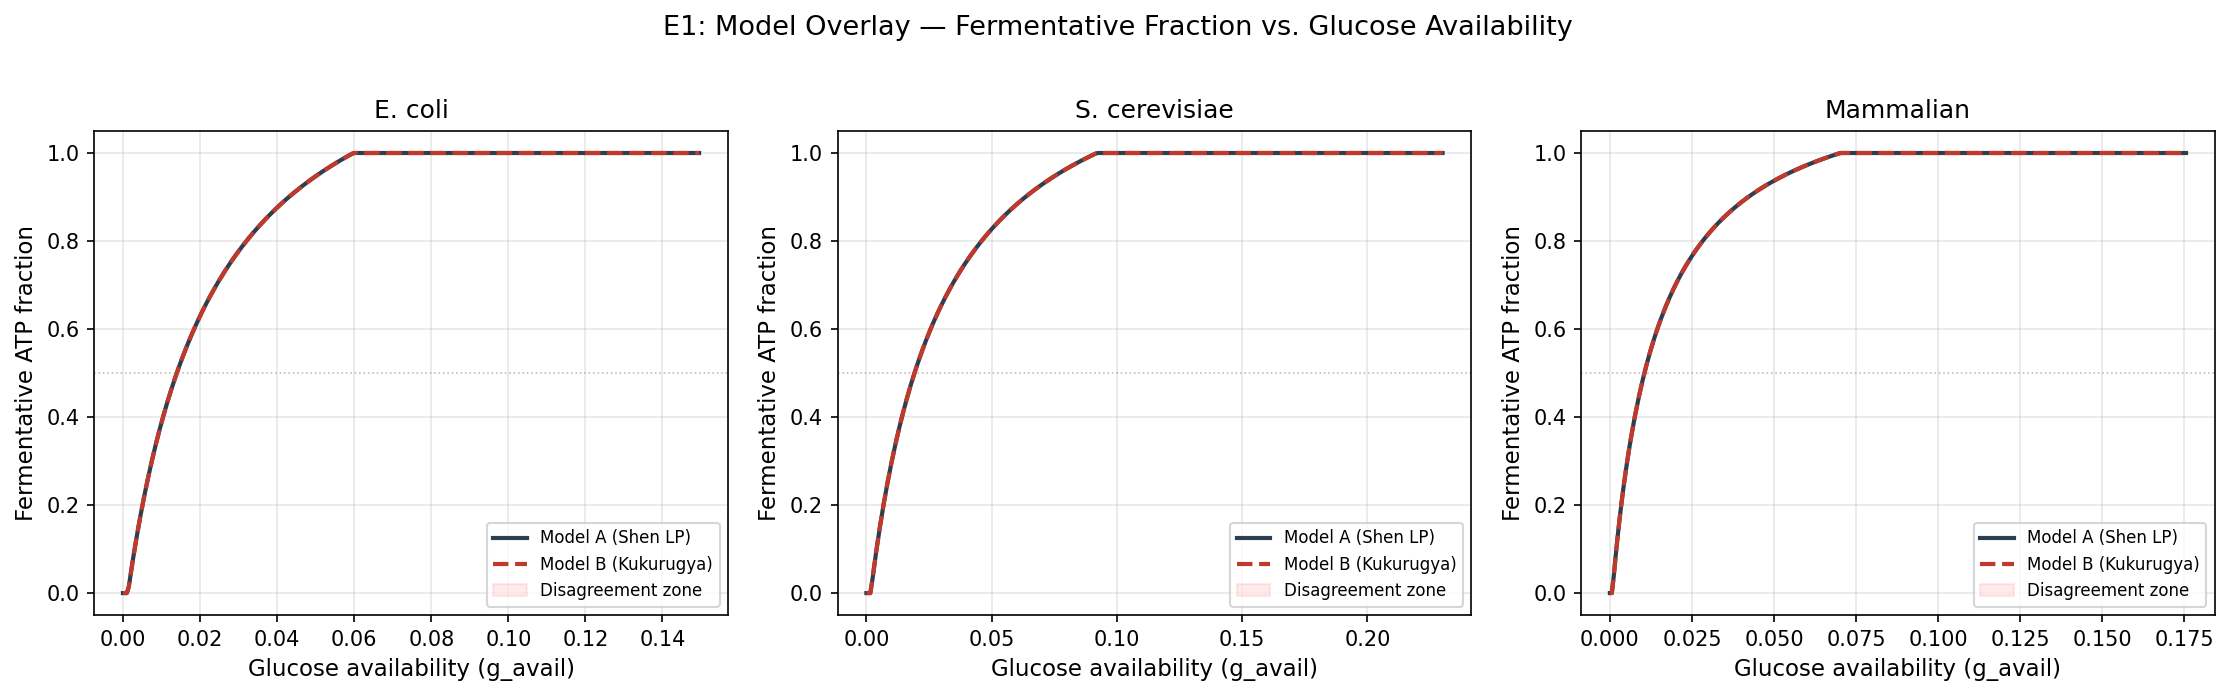

In [7]:
fig = plot_f1_overlay()
plt.show()

### E2 — Kapasitas vs. Realisasi: Titik-Balik Verdict

Eksperimen inti. Saat $u_G = 1$ glikolisis menang (Kukurugya); seiring $u_G$ turun (enzim glikolitik idle — temuan Shen), respirasi menang. Titik-balik terjadi tepat di $u_G = \rho$. Tabel berikut (E2c) memberi titik-balik dengan **interval kepercayaan 90%** dari bootstrap — seluruhnya di bawah 1,0, jadi pembalikan bersifat robust.

In [8]:
e2c = audit_results["e2c"]
e2c[["organism", "nominal_flip_uG", "ci_5", "ci_95"]]

,organism,nominal_flip_uG,ci_5,ci_95
0,ecoli,0.276577,0.158997,0.479131
1,yeast,0.239910,0.139098,0.414457
2,mammalian,0.163604,0.094324,0.284613


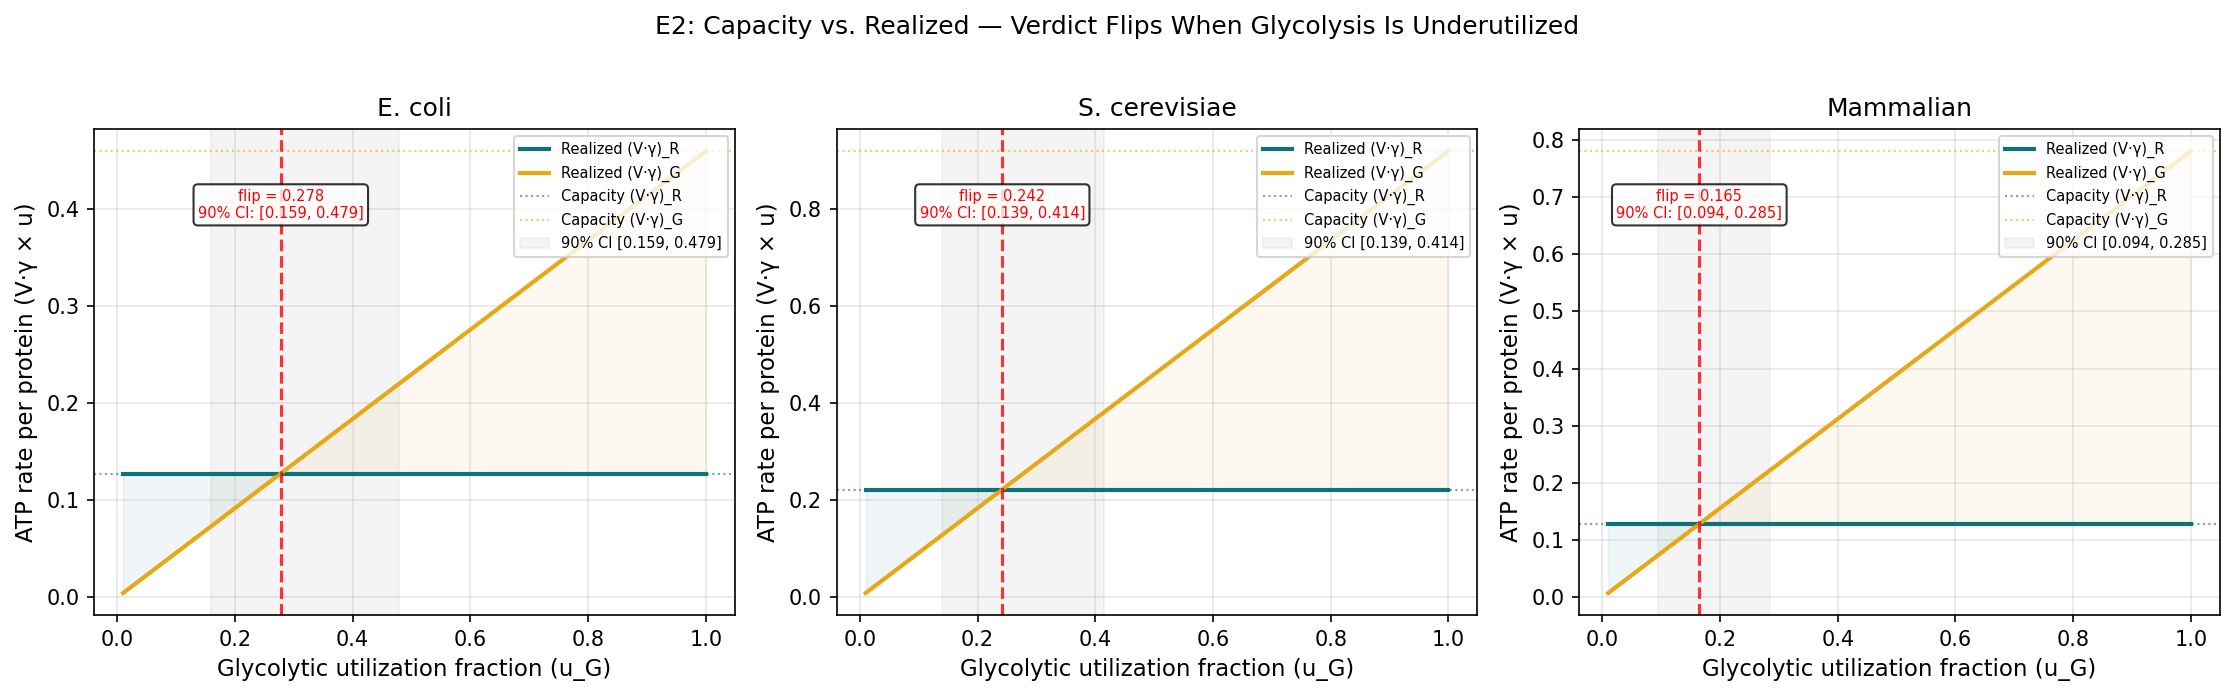

In [9]:
fig = plot_f2_verdict_flip()
plt.show()

### E2d — Dekomposisi Atribusi Enzim

Apakah hasil hanya artefak "enzim mana yang dihitung"? Variasi $\pm 30\%$ reatribusi massa enzim antar jalur memang menggeser $\rho$ dan titik-balik, **namun flip selalu mengikuti $\rho$ secara tepat** — efek reatribusi nyata tapi sekunder dibanding $u_G$.

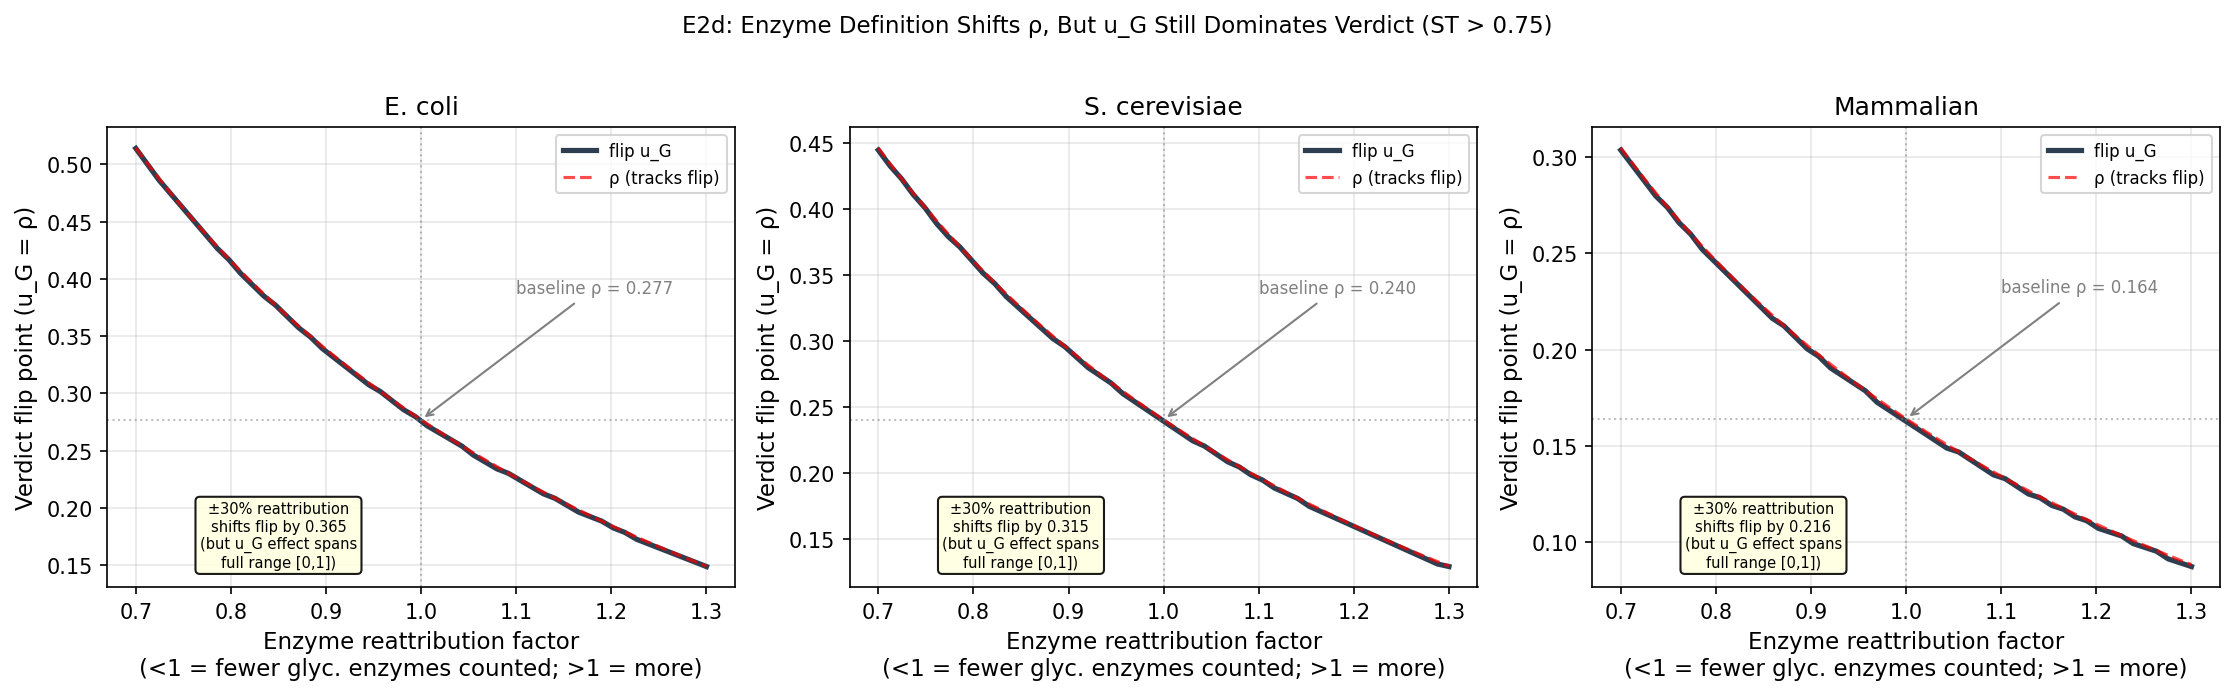

In [10]:
fig = plot_f6_decomposition()
plt.show()

### E4 — Diagram Fase 2D

Memetakan fenotipe metabolik pada grid 2D $(u_G, g_\text{avail})$ sekaligus — **visualisasi orisinal** yang tidak ada di Shen/Kukurugya/Wang. **Temuan:** batas rezim bergeser ke glukosa lebih tinggi seiring $u_G$ menurun — sel dengan enzim glikolitik idle butuh lebih banyak glukosa sebelum beralih ke fermentasi, konsisten dengan mekanisme *proteome hedging* Shen.

Diagram fase: 19200 titik grid


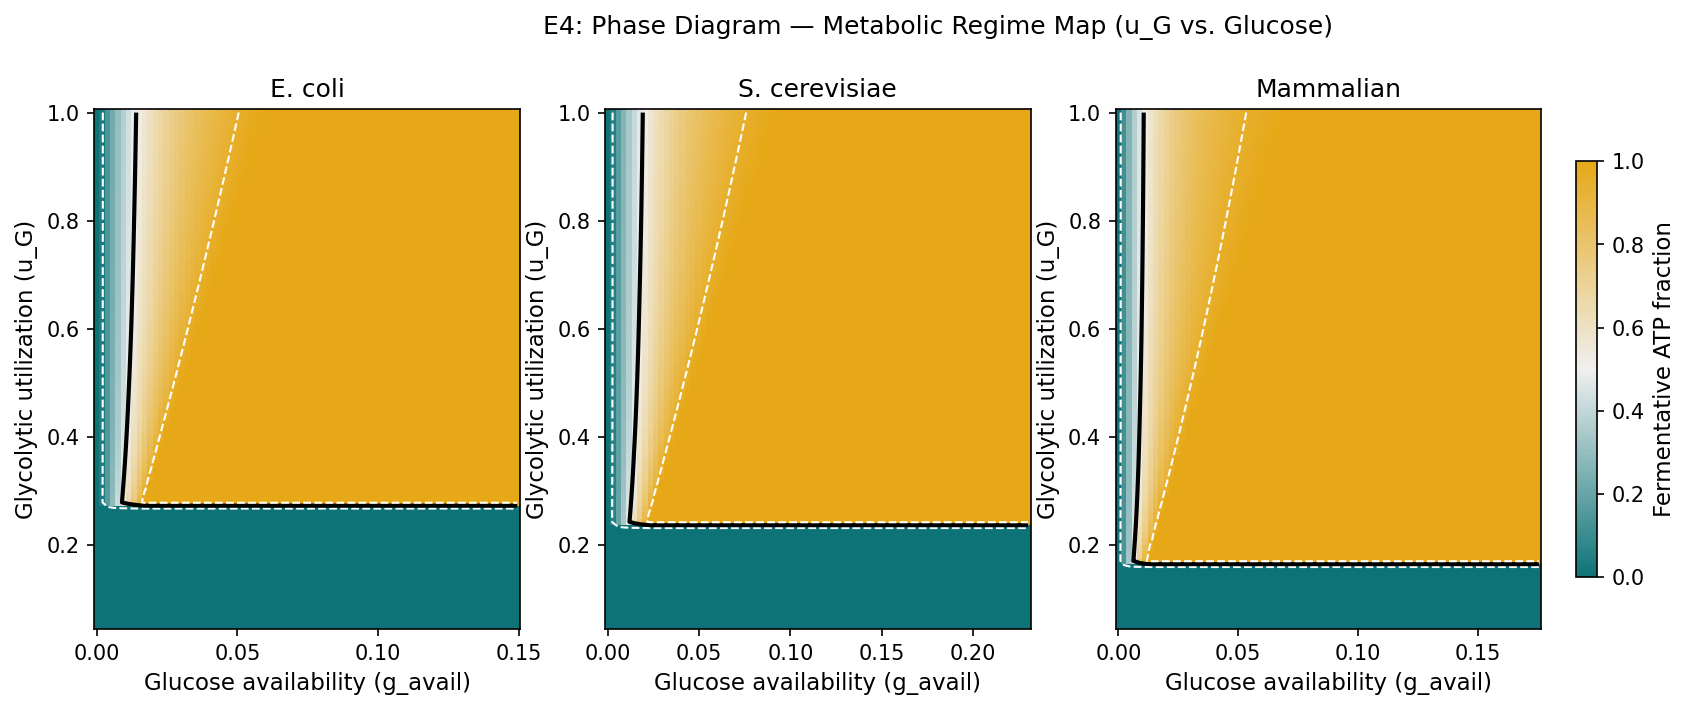

In [11]:
e4_df = run_e4_all_organisms(n_uG=80, n_g=80)
e4_df.to_csv("results/e4_phase_diagram.csv", index=False)
print(f"Diagram fase: {len(e4_df)} titik grid")
fig = plot_f7_phase_diagram()
plt.show()

### Perbandingan dengan Wang 2025

Wang memodelkan penyilangan efisiensi sebagai fungsi kualitas nutrisi $q$. Dalam kerangka kami, variabel setara adalah $u_G$ (kualitas nutrisi tinggi $\leftrightarrow$ $u_G$ rendah). Kedua kerangka memprediksi titik penyilangan yang sama dari sudut mekanistik berbeda — **komplementer**: Wang menjelaskan *mengapa* $u_G$ bervariasi (heterogenitas sel), kami menunjukkan $u_G$ saja cukup menjelaskan perbedaan verdict.

     ecoli: penyilangan di u_G = 0.2770  (Wang q = 0.7230)
     yeast: penyilangan di u_G = 0.2402  (Wang q = 0.7598)
 mammalian: penyilangan di u_G = 0.1641  (Wang q = 0.8359)


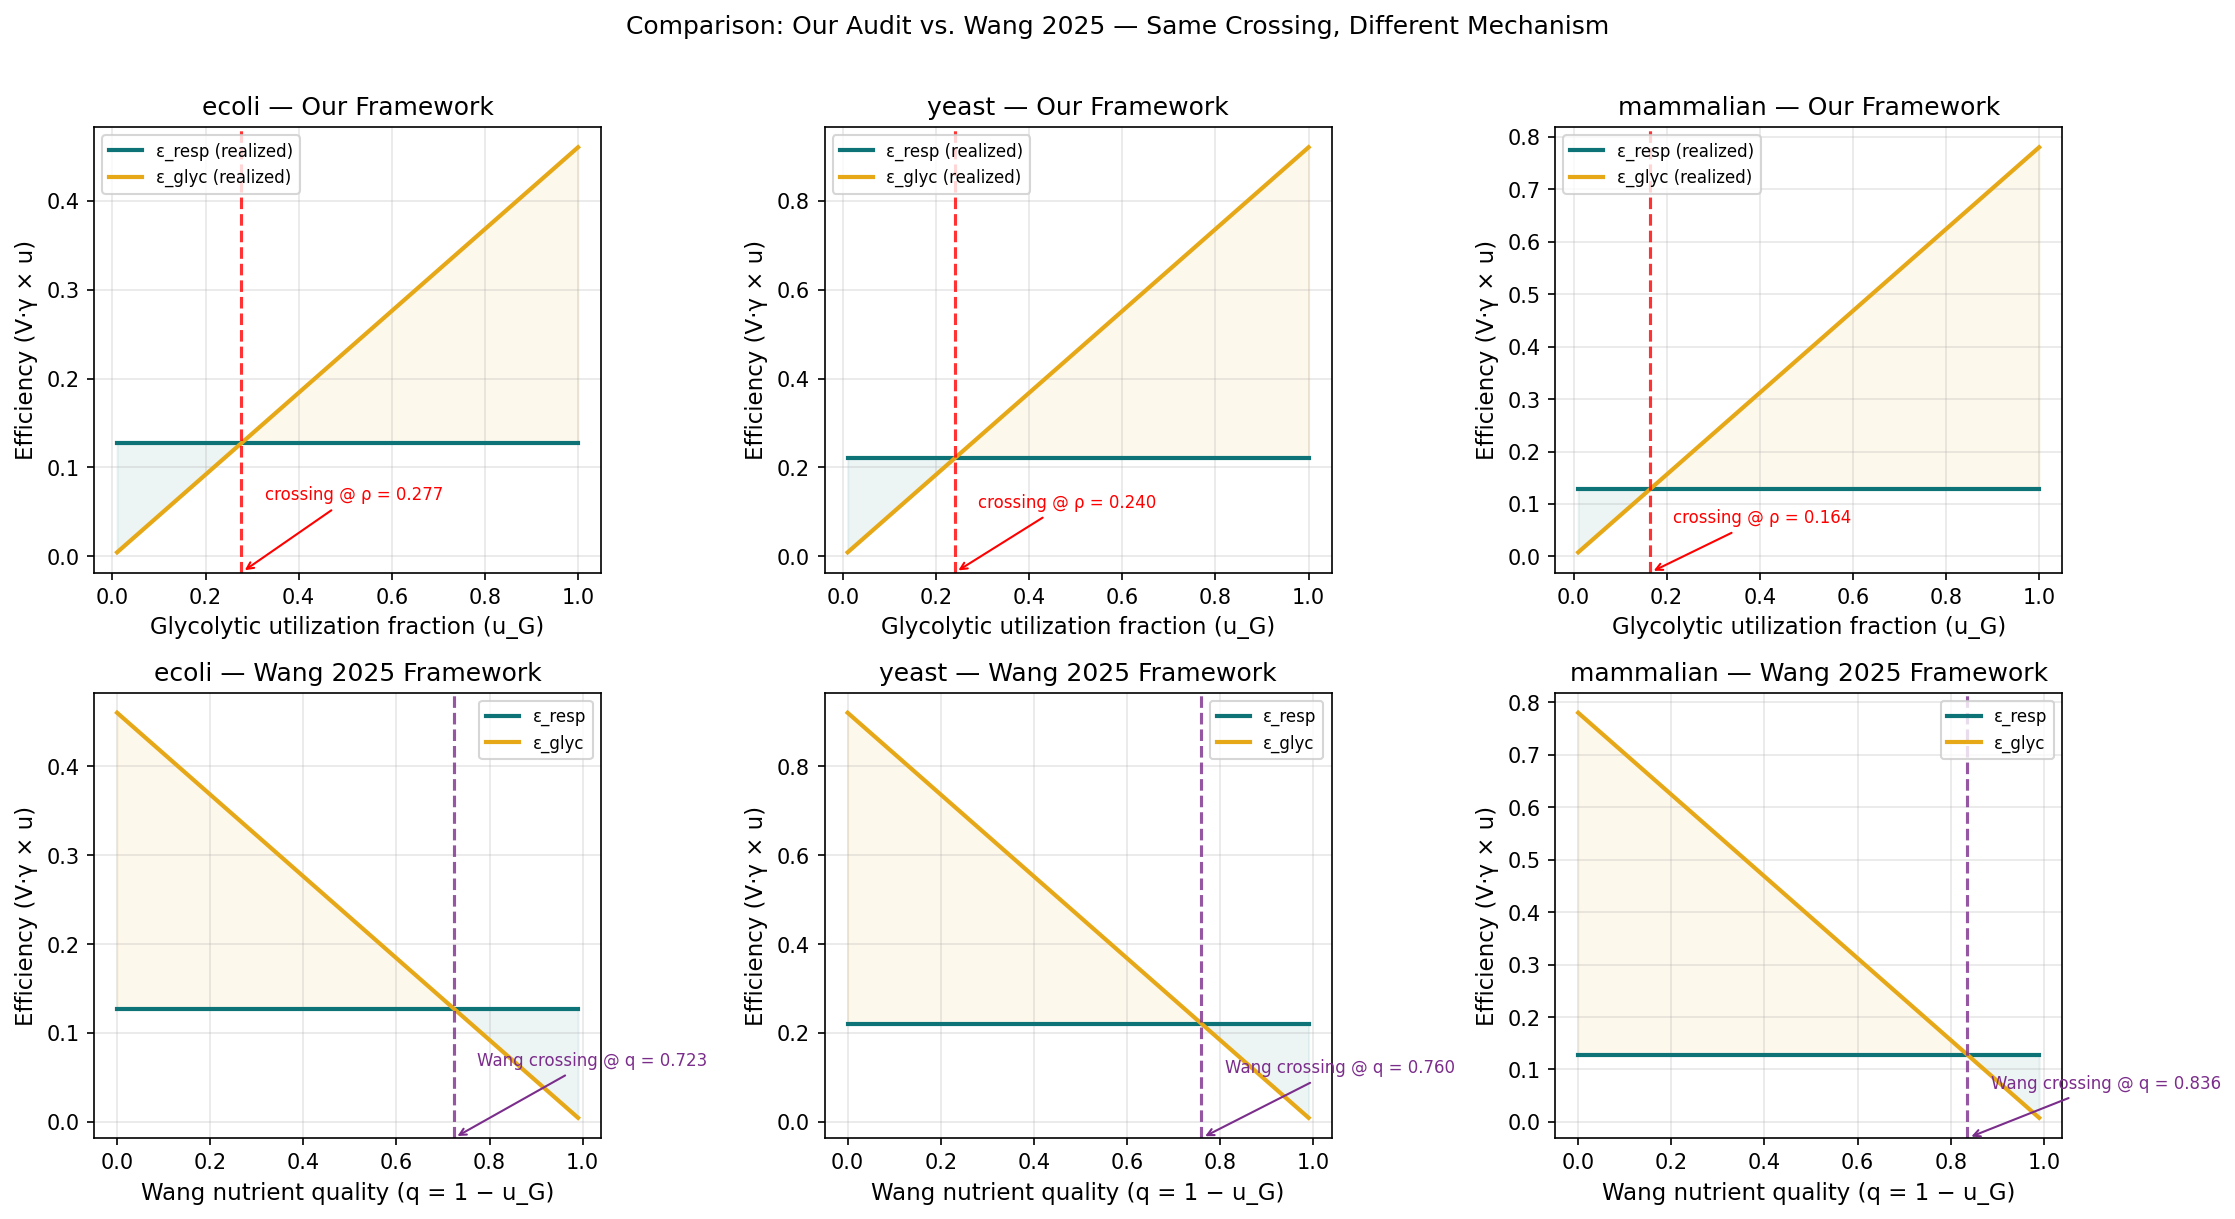

In [12]:
wang_df = run_wang_comparison()
wang_df.to_csv("results/wang_comparison.csv", index=False)
for org in wang_df["organism"].unique():
    cp = wang_df[wang_df["organism"] == org]["crossing_point_uG"].iloc[0]
    print(f"{org:>10}: penyilangan di u_G = {cp:.4f}  (Wang q = {1-cp:.4f})")
fig = plot_f5_wang_comparison()
plt.show()

## M4 — Identifiabilitas: Pengukuran Penuntas

Analisis sensitivitas global menjawab: **pengukuran mana yang, bila dipastikan, paling mengurangi ketidakpastian verdict?** Itulah eksperimen penuntas.

`run_e3()` menjalankan Sobol ($N=1024$) dan Morris ($N=512$) untuk ketiga organisme, pada beberapa keluaran sekaligus (margin linier, ambang $g^*$, **dan keluaran LP nonlinier untuk E3b**).

> ⏱️ **Sel paling lambat (~60s).** Sobol pada keluaran LP menyelesaikan puluhan ribu LP. Mohon tunggu.

In [13]:
e3_results = run_e3()
print("Kunci hasil E3:", list(e3_results.keys()))

[M4] Running Sobol (margin) for ecoli...
[M4] Running Sobol (g*) for ecoli...
[M4] Running Sobol (LP frac_glyc) for ecoli...


[M4] Running Morris (margin) for ecoli...
[M4] Running Morris (g*) for ecoli...
[M4] Running Sobol (margin) for yeast...
[M4] Running Sobol (g*) for yeast...
[M4] Running Sobol (LP frac_glyc) for yeast...


[M4] Running Morris (margin) for yeast...
[M4] Running Morris (g*) for yeast...
[M4] Running Sobol (margin) for mammalian...
[M4] Running Sobol (g*) for mammalian...
[M4] Running Sobol (LP frac_glyc) for mammalian...


[M4] Running Morris (margin) for mammalian...
[M4] Running Morris (g*) for mammalian...

[M4] Top parameters by Sobol total-order (margin output):
  ecoli:
             u_G: ST = 0.7559 ± 0.0595
      gamma_glyc: ST = 0.1221 ± 0.0136
          V_glyc: ST = 0.1221 ± 0.0141
  yeast:
             u_G: ST = 0.7653 ± 0.0594
      gamma_glyc: ST = 0.1236 ± 0.0138
          V_glyc: ST = 0.1236 ± 0.0143
  mammalian:
             u_G: ST = 0.7810 ± 0.0591
      gamma_glyc: ST = 0.1262 ± 0.0142
          V_glyc: ST = 0.1261 ± 0.0147

[M4] Top parameters by Sobol total-order (LP frac_glyc — nonlinear):
  ecoli:
             u_G: ST = 0.6332 ± 0.0688
      gamma_resp: ST = 0.3010 ± 0.0409
      gamma_glyc: ST = 0.2899 ± 0.0501
  yeast:
             u_G: ST = 0.6058 ± 0.0651
      gamma_resp: ST = 0.3429 ± 0.0537
      gamma_glyc: ST = 0.3101 ± 0.0596
  mammalian:
      gamma_resp: ST = 0.4293 ± 0.0787
             u_G: ST = 0.3947 ± 0.0622
      gamma_glyc: ST = 0.3407 ± 0.0525

[M4] Cross-check: 

### E3 — Sobol & Morris pada Margin (Linier)

Untuk ketiga organisme, $u_G$ mendominasi secara konsisten ($S_T \approx 0{,}76$–$0{,}78$); definisi enzim ($V_G$) sekunder ($S_T \approx 0{,}12$). Morris ($\mu^*$ vs $\sigma$) mengkonfirmasi peringkat yang sama.

**Peringatan tautologi:** margin $m = u_R(V\!\cdot\!\gamma)_R - u_G(V\!\cdot\!\gamma)_G$ adalah **linier** di $u_G$, sehingga Sobol nyaris pasti menempatkan $u_G$ teratas. Inilah yang diuji E3b.

In [14]:
sobol_margin = e3_results["sobol_margin"]
sobol_margin.groupby("organism").head(3)[["organism", "parameter", "S1", "ST"]]

,organism,parameter,S1,ST
0,ecoli,u_G,0.714011,0.755887
1,ecoli,gamma_glyc,0.098336,0.122110
2,ecoli,V_glyc,0.094189,0.122092
6,yeast,u_G,0.722827,0.765265
7,yeast,gamma_glyc,0.099576,0.123625
8,yeast,V_glyc,0.095370,0.123607
12,mammalian,u_G,0.737573,0.780972
13,mammalian,gamma_glyc,0.101661,0.126163
14,mammalian,V_glyc,0.097353,0.126144


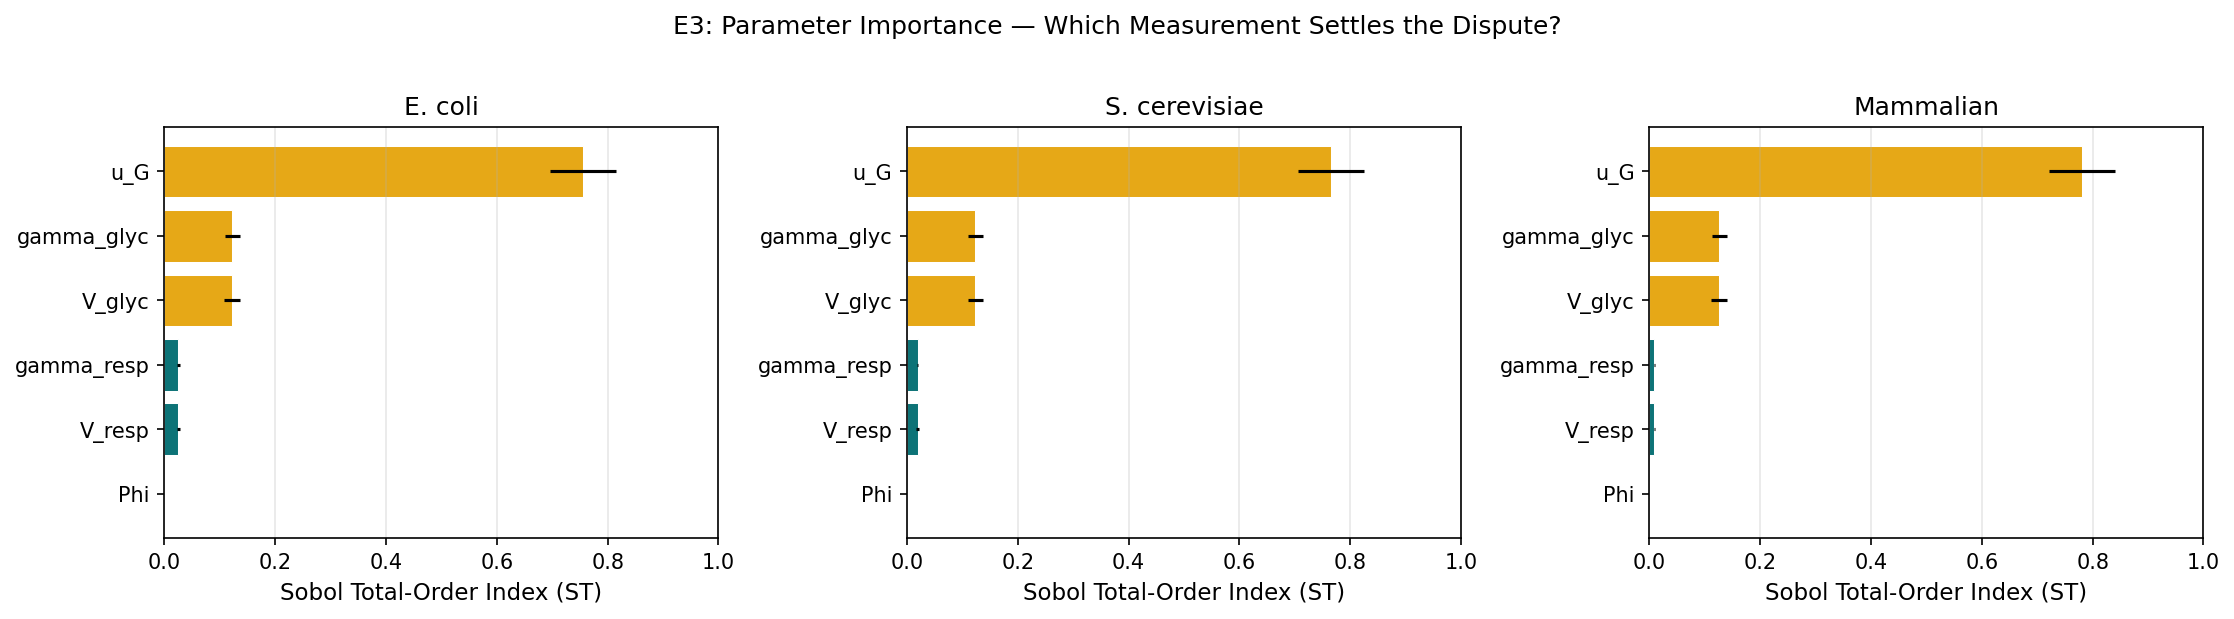

In [15]:
fig = plot_f3_sobol_tornado()
plt.show()

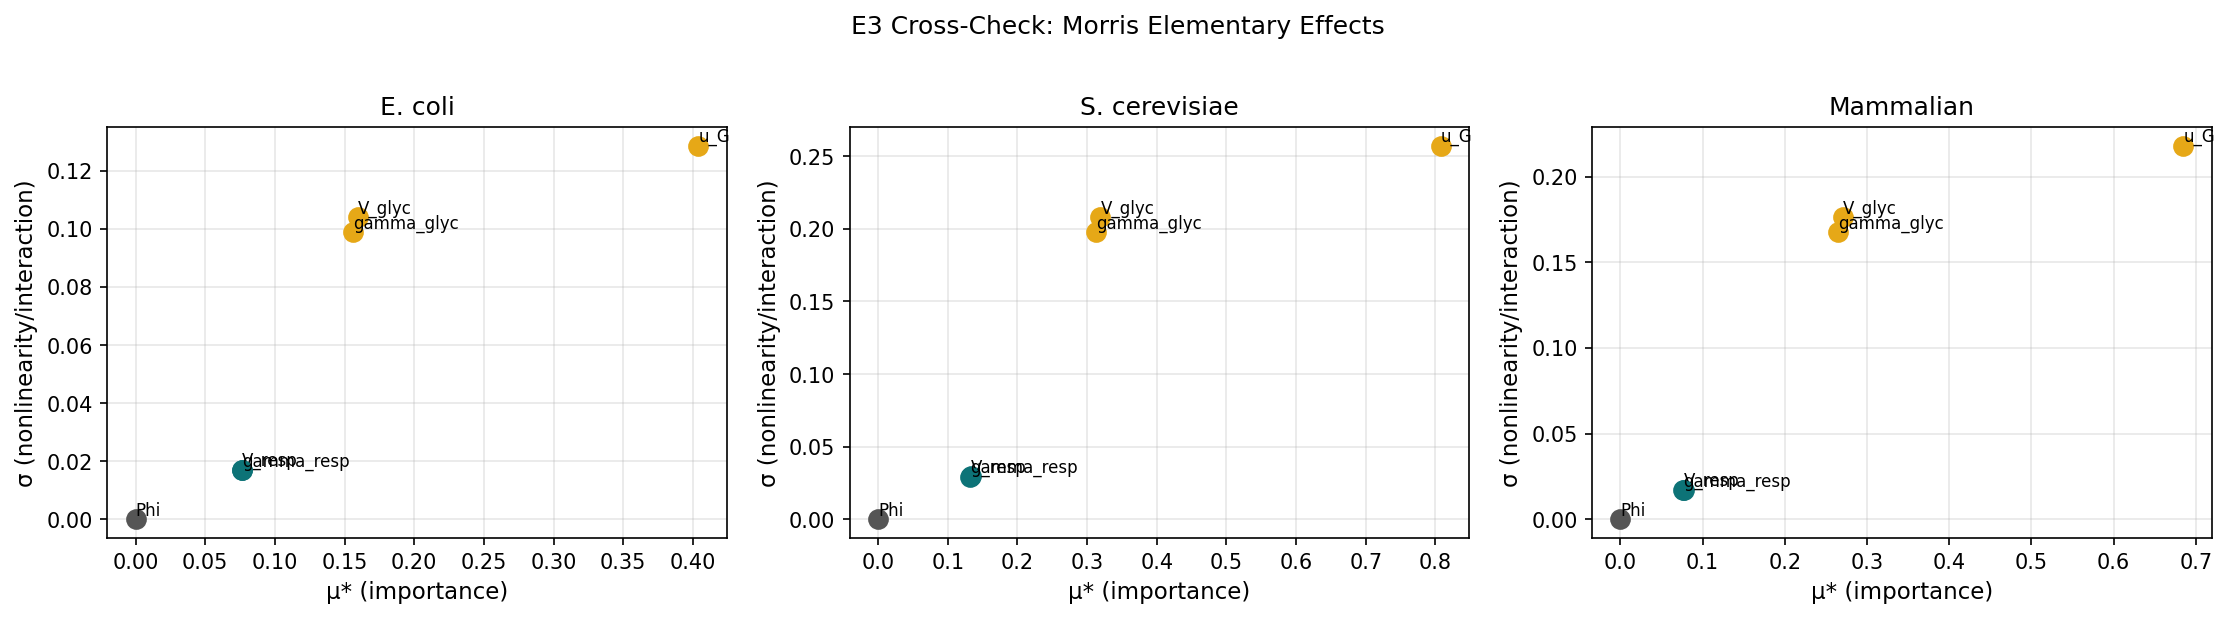

In [16]:
fig = plot_f3_morris_scatter()
plt.show()

### E3b — Sobol pada Keluaran LP (Nonlinier)

Untuk menguji apakah dominasi $u_G$ hanya artefak rumus, E3b menjalankan Sobol pada keluaran **nonlinier** Model A: fraksi fermentatif optimal $f^*_G$ dari LP, dengan $u_G$ memodulasi kapasitas glikolitik efektif ($V_G^\text{eff} = u_G V_G$) sehingga memengaruhi struktur kendala secara nonlinier.

**Temuan baru:** pada keluaran nonlinier, $u_G$ tetap dominan untuk *E. coli* dan ragi, tetapi untuk **sel mamalia $\gamma_R$ mengambil alih peringkat pertama** ($S_T \approx 0{,}43$ vs $0{,}40$). Artinya (i) dominasi $u_G$ bukan sepenuhnya tautologis — ia memang penting secara nonlinier, dan (ii) yield respirasi $\gamma_R$ adalah pengukuran penuntas kedua yang kritis, terutama untuk mamalia — temuan yang tak terlihat dari analisis margin linier.

In [17]:
sobol_lp = e3_results["sobol_lp"]
sobol_lp.groupby("organism").head(2)[["organism", "parameter", "S1", "ST"]]

,organism,parameter,S1,ST
0,ecoli,u_G,0.383727,0.633211
1,ecoli,gamma_resp,0.179825,0.300969
6,yeast,u_G,0.337062,0.605842
7,yeast,gamma_resp,0.201588,0.342861
12,mammalian,gamma_resp,0.270597,0.429262
13,mammalian,u_G,0.170874,0.394718


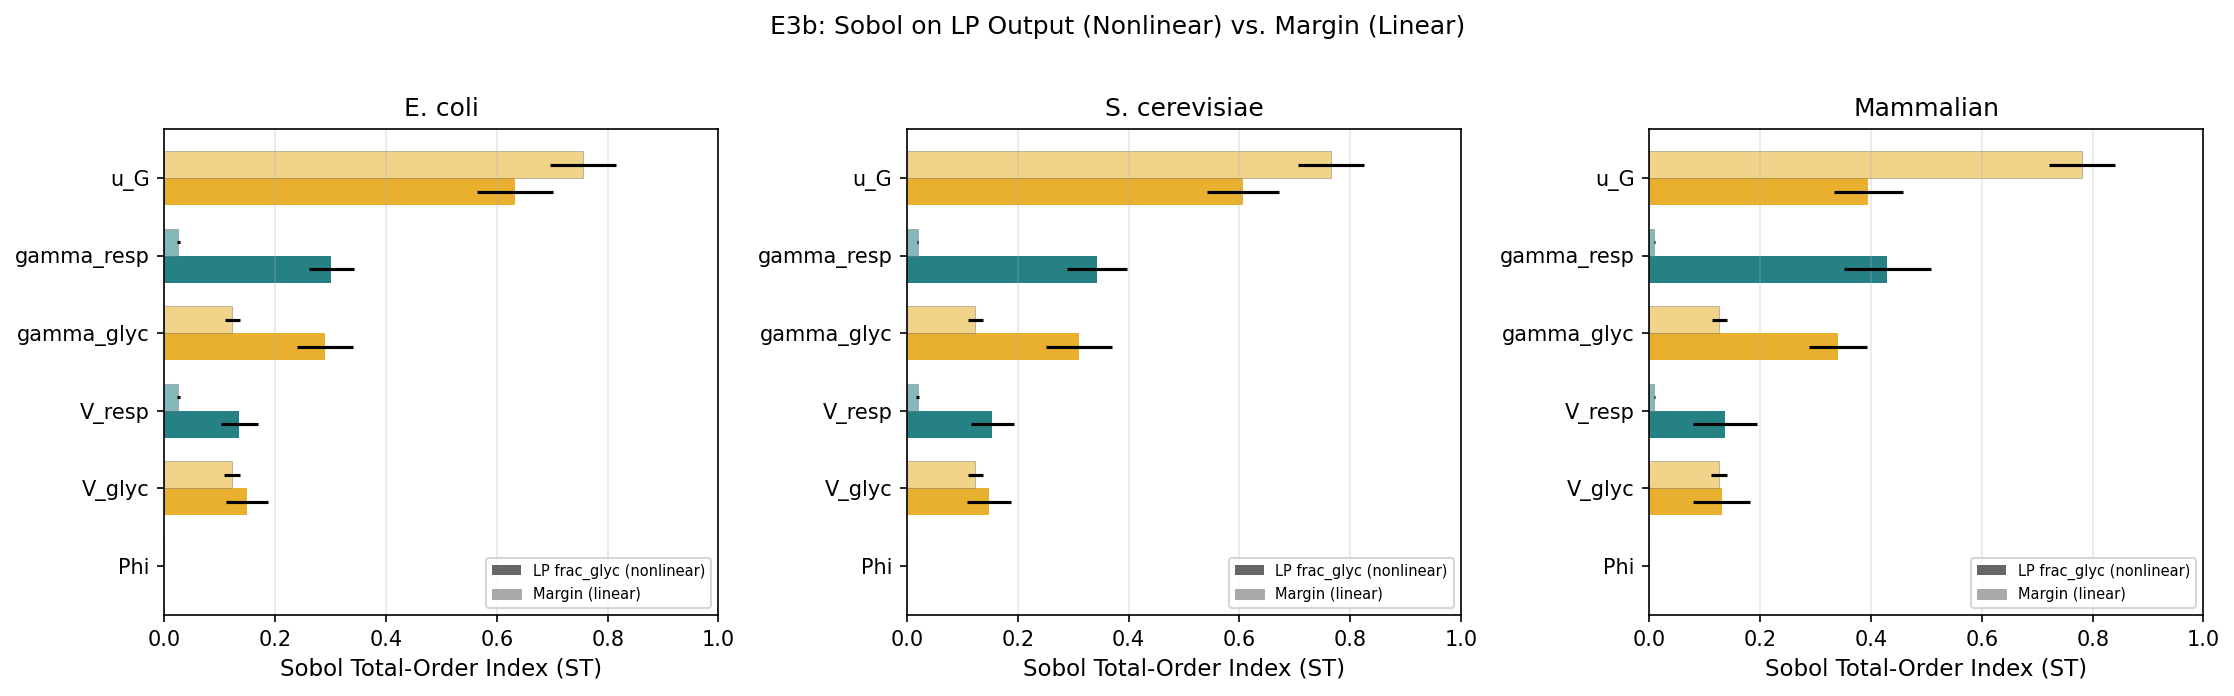

In [18]:
fig = plot_f3c_sobol_lp()
plt.show()

## Kesimpulan

Shen dan Kukurugya **tidak berselisih tentang biologi** — keduanya benar, hanya mengukur hal berbeda. Kukurugya mengukur *kapasitas maksimal* ($V\!\cdot\!\gamma$, $u=1$), Shen mengukur *efisiensi terealisasi* ($u\!\cdot\!V\!\cdot\!\gamma$, dengan enzim glikolitik idle). Verdict membalik pada $u_G \approx \rho$ untuk ketiga organisme (90% CI seluruhnya $< 1{,}0$), konsisten dengan *proteome hedging* yang dilaporkan Shen.

**Pengukuran penuntas:** $u_G$ — fraksi kapasitas enzim glikolitik yang benar-benar dipakai sel in-vivo. Validasi nonlinier (E3b) menambahkan bahwa $\gamma_R$ kritis untuk sel mamalia. Mekanisme penyilangan ini komplementer terhadap pendamaian Wang 2025.

**Rekomendasi kerja masa depan:** (i) ukur $u_G$ in-vivo per organisme via proteomik kuantitatif + fluksomik; (ii) perluas ke model skala-genom (GECKO/ETFL); (iii) integrasikan dengan kerangka heterogenitas Wang.

Kode sumber: https://github.com/reletz/KDS-WarburgEffect

---

*Naufarrel Zhafif Abhista (13523149) · Frederiko Eldad Mugiyono (13523147) · Hasri Fayadh Muqaffa (13523156) · I Made Wiweka Putera (13523160) — Teknik Informatika, Institut Teknologi Bandung*